In [17]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from pathlib import Path
from collections import defaultdict
from sklearn.metrics import classification_report, roc_curve, auc, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class CONFIG:
    TRAIN_PATH = "C:/Users/wikto/Desktop/Google summer of code/dataset/train" 
    VAL_PATH = "C:/Users/wikto/Desktop/Google summer of code/dataset/val"
    
    BATCH_SIZE = 64
    LEARNING_RATE = 1e-3
    DROPOUT = 0.33
    EPOCHS = 10
    DEVICE = "cpu"
    RANDOM_SEED = 58

np.random.seed(CONFIG.RANDOM_SEED)
torch.manual_seed(CONFIG.RANDOM_SEED)

def get_metadata(path):
    main_path = Path(path)
    classes = sorted([f.name for f in main_path.iterdir() if f.is_dir()])
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    
    image_paths = []
    for cls in classes:
        image_paths.extend(list((main_path / cls).glob("*.npy")))
    
    return image_paths, classes, class_to_idx

train_paths, classes, class_to_idx = get_metadata(CONFIG.TRAIN_PATH)
val_paths, _, _ = get_metadata(CONFIG.VAL_PATH)
idx_to_class = {v: k for k, v in class_to_idx.items()}

class GSoCDataset(Dataset):
    def __init__(self, image_paths):
        self.image_paths = image_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        image = np.load(path)
        
        if len(image.shape) == 2:
            image = np.expand_dims(image, axis=0)
        
        image = torch.from_numpy(image).float()
        label = class_to_idx[Path(path).parent.name]
        return image, label

train_loader = DataLoader(GSoCDataset(train_paths), batch_size=CONFIG.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(GSoCDataset(val_paths), batch_size=CONFIG.BATCH_SIZE, shuffle=False)

class ResNet50(nn.Module):
    def __init__(self, n_classes=3):
        super(ResNet50, self).__init__()
        self.backbone = timm.create_model('resnet50', pretrained=True, in_chans=1)
        
        num_ftrs = self.backbone.get_classifier().in_features
        self.backbone.reset_classifier(0) 

        self.classifier = nn.Sequential(
            nn.Linear(num_ftrs, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Dropout(p=CONFIG.DROPOUT),
            nn.Linear(1024, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(p=CONFIG.DROPOUT),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.backbone.forward_features(x)
        x = self.backbone.global_pool(x)
        x = self.classifier(x)
        return x

def train_model():
    model = ResNet50(n_classes=len(classes)).to(CONFIG.DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG.LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()
    
    best_acc = 0

    for epoch in range(CONFIG.EPOCHS):
        model.train()
        train_loss, t_correct, t_total = 0, 0, 0
        
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
            images, labels = images.to(CONFIG.DEVICE), labels.to(CONFIG.DEVICE)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, pred = outputs.max(1)
            t_total += labels.size(0)
            t_correct += pred.eq(labels).sum().item()

        model.eval()
        val_loss, v_correct, v_total = 0, 0, 0
        all_labels, all_probs = [], []
        
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):
                images, labels = images.to(CONFIG.DEVICE), labels.to(CONFIG.DEVICE)
                outputs = model(images)
                
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                probs = F.softmax(outputs, dim=1)
                _, pred = outputs.max(1)
                v_total += labels.size(0)
                v_correct += pred.eq(labels).sum().item()
                
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        t_acc = 100. * t_correct / t_total
        v_acc = 100. * v_correct / v_total
        
        
        print(f"Train Acc: {t_acc}% | Val Acc: {v_acc}% | Val Loss: {val_loss/len(val_loader)}")

        if v_acc > best_acc:
            best_acc = v_acc
            torch.save(model.state_dict(), 'models/resnet50_gsoc_best.pth')
            print("New best, saved")

    return model, np.array(all_labels), np.array(all_probs)


In [10]:
#run
trained_model, y_true, y_probs = train_model()


KeyboardInterrupt: 

In [18]:
#loading model again if neccessary


def get_predictions(model_path, data_loader):
    model = ResNet50(n_classes=3).to(CONFIG.DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=CONFIG.DEVICE))
    model.eval()
    
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc="Preds"):
            images = images.to(CONFIG.DEVICE)
            
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    return np.array(all_labels), np.array(all_probs)

val_loader = DataLoader(GSoCDataset(val_paths), batch_size=CONFIG.BATCH_SIZE, shuffle=False)

y_true, y_probs = get_predictions(
    model_path='models/resnet50_gsoc_best.pth', 
    data_loader=val_loader
)


Preds: 100%|██████████| 118/118 [10:47<00:00,  5.49s/it]


              precision    recall  f1-score   support

          no       0.87      0.98      0.92      2500
      sphere       0.93      0.84      0.88      2500
        vort       0.93      0.91      0.92      2500

    accuracy                           0.91      7500
   macro avg       0.91      0.91      0.91      7500
weighted avg       0.91      0.91      0.91      7500

AUC for no: 0.9867556
AUC for sphere: 0.97125416
AUC for vort: 0.9866124000000001


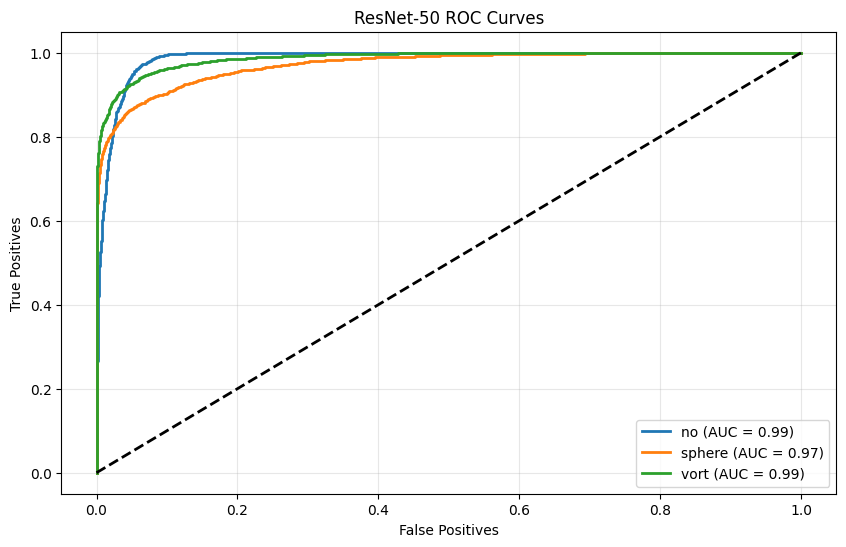

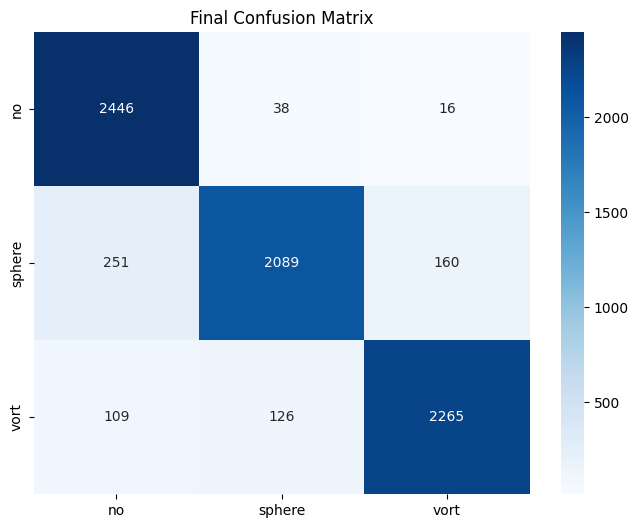

In [22]:
#results

y_pred = np.argmax(y_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=classes))


plt.figure(figsize=(10, 6))
y_true_onehot = np.eye(len(classes))[y_true]
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_probs[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'{classes[i]} (AUC = {auc(fpr, tpr):.2f})')

auc_per_class = roc_auc_score(y_true_onehot, y_probs, average=None)
for i, class_name in enumerate(classes):
    print(f"AUC for {class_name}: {auc_per_class[i]}")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('ResNet-50 ROC Curves')
plt.xlabel('False Positives')
plt.ylabel('True Positives')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Final Confusion Matrix')
plt.show()